# Assignment 2. Option 2

## Dataset Exploration

In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
!bash ./src/download_voxconverse.sh

Annotations already present, skipping clone.
Audio already present, skipping download.


## Pyannote-Based System

## Custom Implementation (PyTorch / Torchaudio / PyTorch-Lightning)

In [ ]:
from pathlib import Path
from src.dataset import VoxConverseDataset, AudioSampler, make_collate_fn
from src.models import MelSpectrogramExtractor, VoiceActivityDetector
from src.train import train_vad, plot_history
from torch.utils.data import DataLoader
import soundfile as sf
import pandas as pd
import torch
import matplotlib.pyplot as plt

DATA_DIR = Path("data")
AUDIO_DIR = DATA_DIR / "audio"
ANNOTATIONS_DIR = DATA_DIR / "annotations"
IMG_DIR = Path("img")
MODELS_DIR = Path("models")
DIR_DEV = "dev"
DIR_TEST = "test"
SAMPLE_RATE = 16_000
HOP = 10
VAD_MODEL = MODELS_DIR / "vad.pt"

device = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"

In [22]:
dataset_dev = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_DEV,
  audio_dir=AUDIO_DIR / DIR_DEV,
  sample_rate=SAMPLE_RATE,
)

dataset_test = VoxConverseDataset(
  annotations_dir=ANNOTATIONS_DIR / DIR_TEST,
  audio_dir=AUDIO_DIR / DIR_TEST,
  sample_rate=SAMPLE_RATE,
)

dev_lengths  = [sf.info(p).frames for p in dataset_dev.audio_files]
test_lengths = [sf.info(p).frames for p in dataset_test.audio_files]

dataloader_dev = DataLoader(
  dataset_dev,
  batch_sampler=AudioSampler(dev_lengths, batch_size=8, shuffle=True),
  collate_fn=make_collate_fn(HOP, SAMPLE_RATE),
)

dataloader_test = DataLoader(
  dataset_test,
  batch_sampler=AudioSampler(dev_lengths, batch_size=8, shuffle=False),
  collate_fn=make_collate_fn(HOP, SAMPLE_RATE),
)

In [24]:
import librosa

pd.Series(
    [librosa.get_samplerate(f) for f in dataset_dev.audio_files + dataset_test.audio_files]
).value_counts()

16000    448
Name: count, dtype: int64

In [ ]:
from src.dataset import RTTM_COLUMNS

dev_path = ANNOTATIONS_DIR / DIR_DEV
test_path = ANNOTATIONS_DIR / DIR_TEST

def prep_data(path):
    return pd.concat(
        [pd.read_csv(f, sep=r"\s+", header=None, names=RTTM_COLUMNS) for f in path.iterdir()],
        ignore_index=True,
    )

dataset_dev.annotations

df_dev = prep_data(dev_path)
df_test = prep_data(test_path)


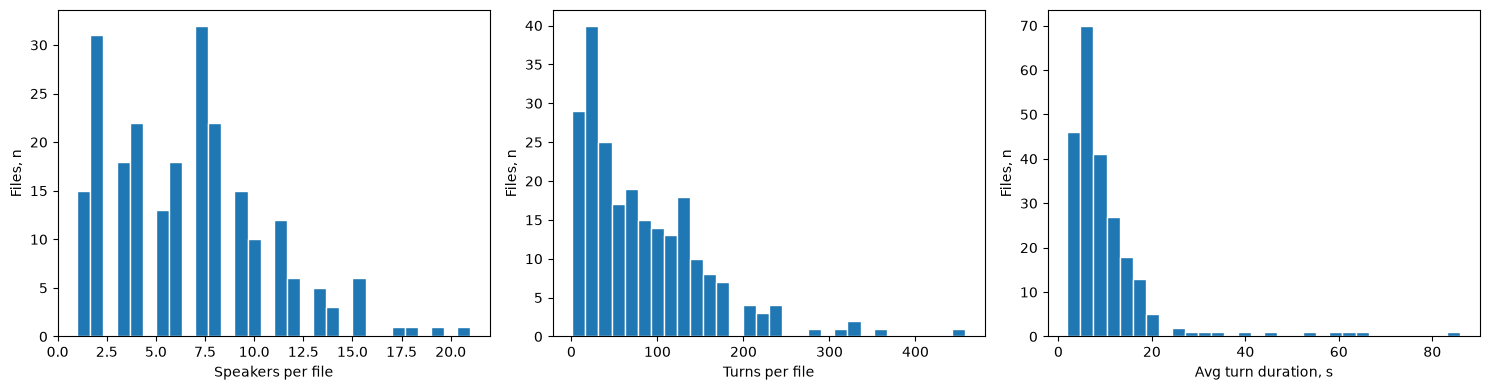

In [ ]:
import matplotlib.pyplot as plt

stats = df_test.groupby("file_id").agg(
    n_speakers=("speaker", "nunique"),
    n_turns=("speaker", "count"),
    avg_turn_dur=("duration", "mean"),
)

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, col, xlabel in zip(
    axes,
    ["n_speakers", "n_turns", "avg_turn_dur"],
    ["Speakers per file", "Turns per file", "Avg turn duration, s"],
):
    ax.hist(stats[col], bins=30, edgecolor="white")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Files, n")
    ax.grid(False)

plt.tight_layout()
plt.show()



### A Voice Activity Detection (VAD) model using a supervised neural network approach

<div align="center"><img src="img/vad.png" height="800"></div>

In [ ]:
VAD_RETRAIN=False

vad = VoiceActivityDetector(
  device=device,
  spectrogram_layer=MelSpectrogramExtractor(
    sample_rate=SAMPLE_RATE,
    hop_ms=HOP,
  )
)

if VAD_MODEL.exists() and not VAD_RETRAIN:
  vad.load_state_dict(torch.load(VAD_MODEL, weights_only=True))
  print(f"VAD loaded from {VAD_MODEL}")
else:
  epochs = 7
  lr = 1e-3

  print(f"Device: {device}")

  history = train_vad(vad, device, lr, epochs, dataloader_dev, dataloader_test)
  fig = plot_history(history)
  fig.savefig(IMG_DIR / "vad_metrics.png", dpi=150, bbox_inches="tight")
  fig.show()

  torch.save(vad.state_dict(), MODELS_DIR / "vad.pt")

VAD loaded from models/vad.pt


23842 -> 746   ratio: 31.959785522788202


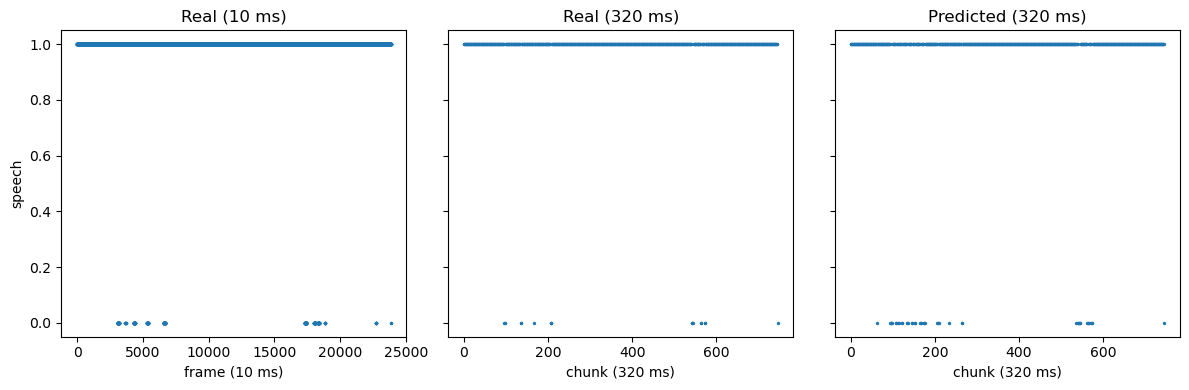

In [58]:
(waveform, labels, mask) = next(iter(dataloader_dev))

m10 = mask[0]
y10 = labels[0][m10].numpy()

with torch.no_grad():
    vad.eval()
    x = tuple(t for t in (waveform, labels, mask))
    pred, labels_c, mask_c = vad(x)          # each is (B, n_chunks)

    m0     = mask_c[0]                        # clip 0's valid chunks
    truth0 = labels_c[0][m0].cpu().numpy()    # clip 0 @ 320 ms, truth
    pred0  = (torch.sigmoid(pred[0]) > 0.5)[m0].cpu().numpy()   # clip 0 @ 320 ms, pred

print(len(y10), "->", len(truth0), "  ratio:", len(y10) / len(truth0))  # expect ~32

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4), sharey=True)

ax1.scatter(range(len(y10)), y10, s=2)
ax1.set(title="Real (10 ms)", xlabel="frame (10 ms)", ylabel="speech")

ax2.scatter(range(len(truth0)), truth0, s=2)
ax2.set(title="Real (320 ms)", xlabel="chunk (320 ms)")

ax3.scatter(range(len(pred0)), pred0, s=2)
ax3.set(title="Predicted (320 ms)", xlabel="chunk (320 ms)")

fig.tight_layout()


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TDNN(nn.Module):
    def __init__(self, in_dim, out_dim, k, d=1):
        super().__init__()
        self.conv = nn.Conv1d(in_dim, out_dim, kernel_size=k, dilation=d)
        self.bn = nn.BatchNorm1d(out_dim)

    def forward(self, x):
        return torch.relu(self.bn(self.conv(x)))


class StatsPool(nn.Module):
    def forward(self, x):
        mean = x.mean(dim=-1)
        std = x.std(dim=-1)
        return torch.cat([mean, std], dim=-1)


class XVector(nn.Module):
    def __init__(self, n_mels=40, emb_dim=512, n_speakers=100):
        super().__init__()
        self.frame = nn.Sequential(
            TDNN(n_mels, 512, k=5, d=1),
            TDNN(512, 512, k=3, d=2),
            TDNN(512, 512, k=3, d=3),
            TDNN(512, 512, k=1, d=1),
            TDNN(512, 1500, k=1, d=1),
        )
        self.pool = StatsPool()
        self.seg1 = nn.Linear(3000, emb_dim)
        self.seg_bn = nn.BatchNorm1d(emb_dim)
        self.seg2 = nn.Linear(emb_dim, emb_dim)
        self.head = nn.Linear(emb_dim, n_speakers)

    def forward(self, feats, return_embedding=False):
        h = self.frame(feats)
        h = self.pool(h)
        emb = self.seg1(h)
        if return_embedding:
            return F.normalize(emb, dim=1)
        h = self.seg2(torch.relu(self.seg_bn(torch.relu(emb))))
        return self.head(h) 

### A segmentation model utilizing permutation invariant CE loss.

In [6]:
import torch
print(torch.backends.mps.is_available())

True
